In [1]:
import sys
print(sys.executable)
sys.path.insert(0,'/lustre/orion/scratch/emgreen/fus145/python_kit')

import history as His
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import scipy.interpolate as spi
from scipy.fftpack import fft
import snapshot as Snap
import matplotlib.cm as cm
import pandas as pd

import csv
import equilibrium as Eq
import data1d
import math
from scipy.interpolate import griddata
import gtc
plt.rcParams['font.family'] = 'Liberation Serif'
from matplotlib.font_manager import FontProperties
plt.rcParams['mathtext.fontset'] = 'stix'
import importlib
importlib.reload(data1d)

def plot_profiles(case_path,fast = False, vs_r = True):
    (physical_parameters,radial_grid,radial_profile)=gtc.read(case_path+"/gtc.out0")
    EDEN0=1#physical_parameters['EDEN0']
    ETEMP0=1#physical_parameters['ETEMP0']
    RHO0=1#physical_parameters['RHO0']
    R0=1#physical_parameters['R0']
    print(physical_parameters)
    (pdata,spdata)=Eq.read(case_path+"/equilibrium.out")
    x=pdata[:,0]
    r=pdata[:,23]
    psi=pdata[:,18]
    n_i=pdata[:,10]*EDEN0
    n_e=pdata[:,6]*EDEN0
    n_f=pdata[:,14]*EDEN0
    kappa_n_i=pdata[:,11]
    kappa_n_e=pdata[:,7]
    T_i=pdata[:,8]*ETEMP0
    T_e=pdata[:,4]*ETEMP0
    T_f=pdata[:,12]*ETEMP0
    kappa_T_i=pdata[:,9]
    kappa_T_e=pdata[:,5]
    q=abs(pdata[:,19])

    plt.figure(figsize=(12,10),dpi=120)
    plt.subplot(321)
    if (vs_r):
        plt.plot(r,n_i,label ='$n_i$')
        plt.plot(r,n_e,label ='$n_e$')
        if fast:
            plt.plot(r,n_f,label ='$n_f$')
        plt.xlabel('$r$',fontsize=15)
        plt.ylabel('$n cm^-3$',fontsize=15)
        plt.legend()

        plt.subplot(322)
        plt.plot(r,T_i,label ='$T_i$')
        plt.plot(r,T_e,label ='$T_e$')
        if fast:
            plt.plot(r,T_f,label ='$T_f$')
        plt.xlabel('$r$',fontsize=15)
        plt.ylabel('$T keV$',fontsize=15)
        plt.legend()

        plt.subplot(323)
        plt.plot(r,kappa_n_i)
        plt.xlabel('$r$',fontsize=15)
        plt.ylabel('$\\kappa_{n_i}$',fontsize=15)

        plt.subplot(324)
        plt.plot(r,kappa_T_i)
        plt.xlabel('$r$',fontsize=15)
        plt.ylabel('$\\kappa_{T_i}$',fontsize=15)


        kappa_n_i_r=kappa_n_i[1:-1]*(x[:-2]-x[2:])/(r[:-2]-r[2:])
        kappa_n_e_r=kappa_n_e[1:-1]*(x[:-2]-x[2:])/(r[:-2]-r[2:])

        kappa_T_i_r=kappa_T_i[1:-1]*(x[:-2]-x[2:])/(r[:-2]-r[2:])
        kappa_T_e_r=kappa_T_e[1:-1]*(x[:-2]-x[2:])/(r[:-2]-r[2:])

        kappa_n_i_r=np.concatenate(([kappa_n_i_r[0]],kappa_n_i_r,[kappa_n_i_r[-1]]))
        kappa_T_i_r=np.concatenate(([kappa_T_i_r[0]],kappa_T_i_r,[kappa_T_i_r[-1]]))

        kappa_n_e_r=np.concatenate(([kappa_n_e_r[0]],kappa_n_e_r,[kappa_n_e_r[-1]]))
        kappa_T_e_r=np.concatenate(([kappa_T_e_r[0]],kappa_T_e_r,[kappa_T_e_r[-1]]))

        plt.subplot(325)
        plt.plot(r,kappa_n_i_r)
        plt.xlabel('$r$',fontsize=15)
        plt.ylabel('$\\kappa_{n_i}$',fontsize=15)

        plt.subplot(326)
        plt.plot(r,kappa_T_i_r)
        plt.xlabel('$r$',fontsize=15)
        plt.ylabel('$\\kappa_{T_i}$',fontsize=15)

        plt.figure()
        plt.plot(r/r[-1],q)
        plt.ylabel('$q$',fontsize=15)
        plt.xlabel('$r$',fontsize=15)

        plt.figure()
        plt.plot(r/r[-1],kappa_T_i/kappa_n_i)
        plt.ylabel('$\\eta_i$',fontsize=15)
        plt.xlabel('$r$',fontsize=15)
    else:
        plt.plot(x,n_i,label ='$n_i$')
        plt.plot(x,n_e,label ='$n_e$')
        if fast:
            plt.plot(x,n_f,label ='$n_f$')
        plt.xlabel('$\\psi$',fontsize=15)
        plt.ylabel('$n cm^-3$',fontsize=15)
        plt.legend()

        plt.subplot(322)
        plt.plot(x,T_i,label ='$T_i$')
        plt.plot(x,T_e,label ='$T_e$')
        if fast:
            plt.plot(x,T_f,label ='$T_f$')
        plt.xlabel('$\\psi$',fontsize=15)
        plt.ylabel('$T keV$',fontsize=15)
        plt.legend()

        plt.subplot(323)
        plt.plot(x,kappa_n_i)
        plt.xlabel('$\\psi$',fontsize=15)
        plt.ylabel('$\\kappa_{n_i}$',fontsize=15)

        plt.subplot(324)
        plt.plot(x,kappa_T_i)
        plt.xlabel('$\\psi$',fontsize=15)
        plt.ylabel('$\\kappa_{T_i}$',fontsize=15)


        kappa_n_i_r=kappa_n_i[1:-1]*(x[:-2]-x[2:])/(r[:-2]-r[2:])
        kappa_n_e_r=kappa_n_e[1:-1]*(x[:-2]-x[2:])/(r[:-2]-r[2:])

        kappa_T_i_r=kappa_T_i[1:-1]*(x[:-2]-x[2:])/(r[:-2]-r[2:])
        kappa_T_e_r=kappa_T_e[1:-1]*(x[:-2]-x[2:])/(r[:-2]-r[2:])

        kappa_n_i_r=np.concatenate(([kappa_n_i_r[0]],kappa_n_i_r,[kappa_n_i_r[-1]]))
        kappa_T_i_r=np.concatenate(([kappa_T_i_r[0]],kappa_T_i_r,[kappa_T_i_r[-1]]))

        kappa_n_e_r=np.concatenate(([kappa_n_e_r[0]],kappa_n_e_r,[kappa_n_e_r[-1]]))
        kappa_T_e_r=np.concatenate(([kappa_T_e_r[0]],kappa_T_e_r,[kappa_T_e_r[-1]]))

        plt.subplot(325)
        plt.plot(x,kappa_n_i_r)
        plt.xlabel('$\\psi$',fontsize=15)
        plt.ylabel('$\\kappa_{n_i}$',fontsize=15)

        plt.subplot(326)
        plt.plot(x,kappa_T_i_r)
        plt.xlabel('$\\psi$',fontsize=15)
        plt.ylabel('$\\kappa_{T_i}$',fontsize=15)

        plt.figure()
        plt.plot(x/x[-1],q)
        plt.ylabel('$q$',fontsize=15)
        plt.xlabel('$\\psi$',fontsize=15)

        plt.figure()
        plt.plot(x/x[-1],kappa_T_i/kappa_n_i)
        plt.ylabel('$\\eta_i$',fontsize=15)
        plt.xlabel('$\\psi$',fontsize=15)


/ccs/home/emgreen/gvec/bin/python


# Er calculation
Use data1d.compare_profile_vs_time()
diagnostic= 4 and species = 0 for radial electric field in kv/m 
species =   0: ions
            1: electrons
            2: fast ions

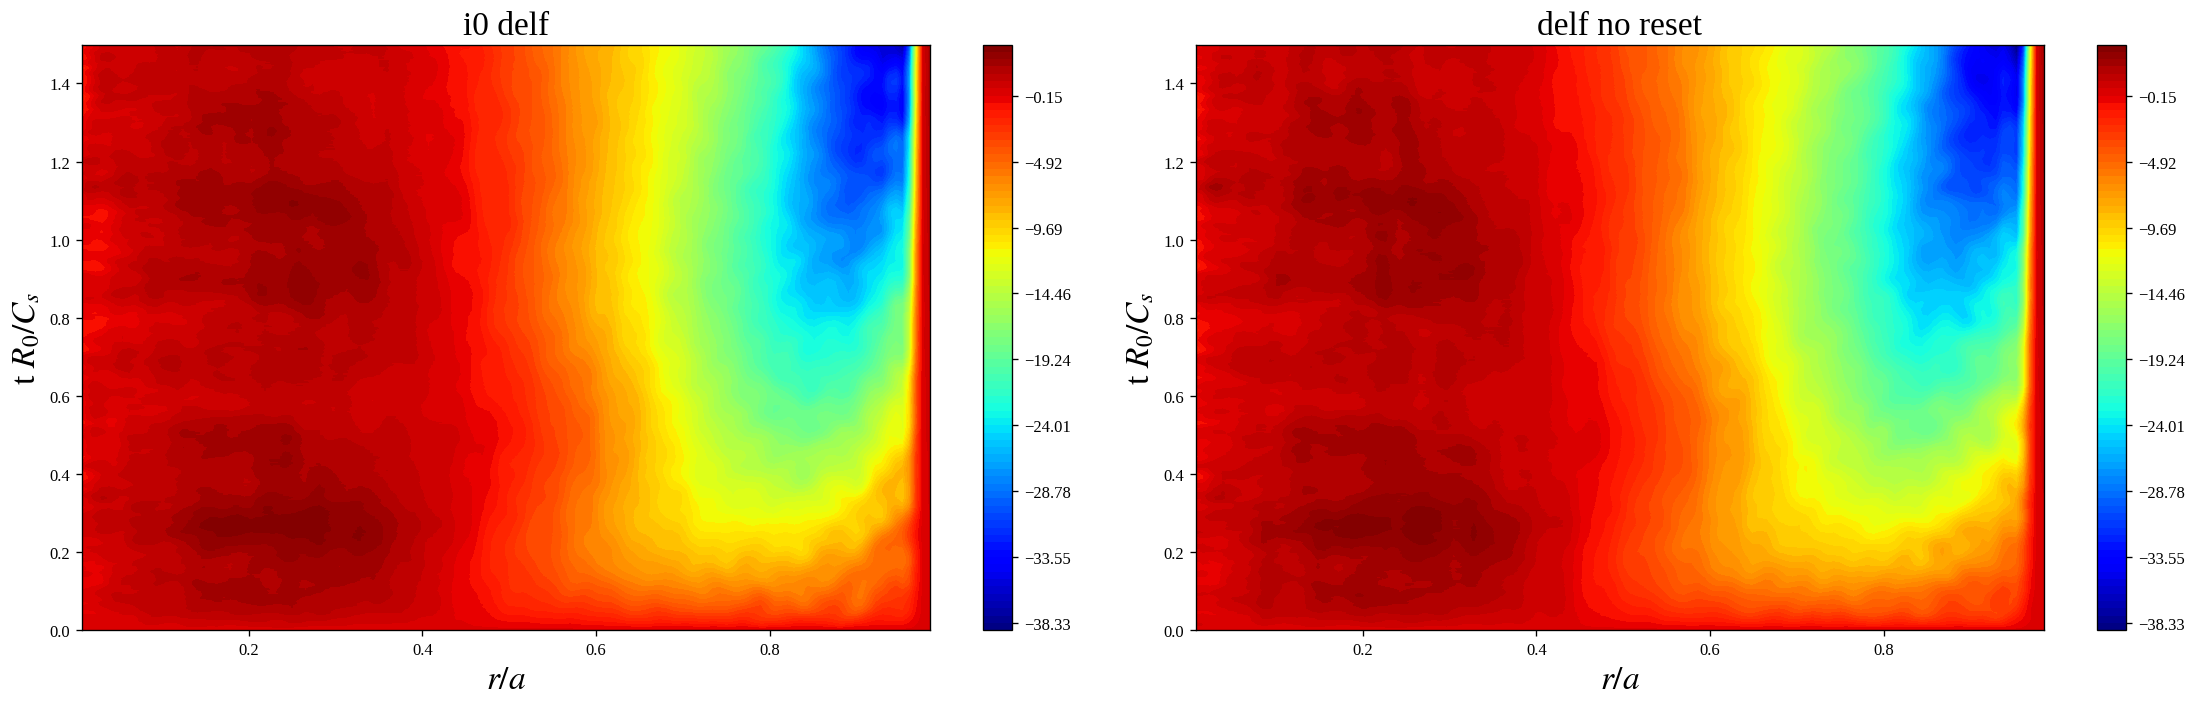

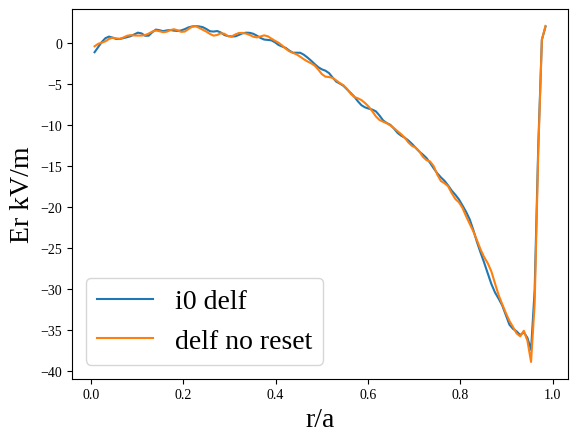

(<Figure size 2280x720 with 4 Axes>,
 <module 'matplotlib.pyplot' from '/ccs/home/emgreen/gvec/lib/python3.13/site-packages/matplotlib/pyplot.py'>)

In [ ]:
#Use diagnostic
data1d.compare_profile_vs_time(
    case_paths=["/lustre/orion/scratch/emgreen/fus145/stellarator/self_consistent_Er/2024_experiment/192111/45_ii0_delf",
                "/lustre/orion/scratch/emgreen/fus145/stellarator/self_consistent_Er/2024_experiment/192111/45_delf_no_reset",
                ],
    title=['i0 delf','delf no reset','delf no0'],
    ndstep=8000,
    ndstart=2000,
    tstep=0.00025,
    psi_trim_low=0,
    psi_trim_high=0,
    diagnostic=4,
    species=0,
    levels = 80
)

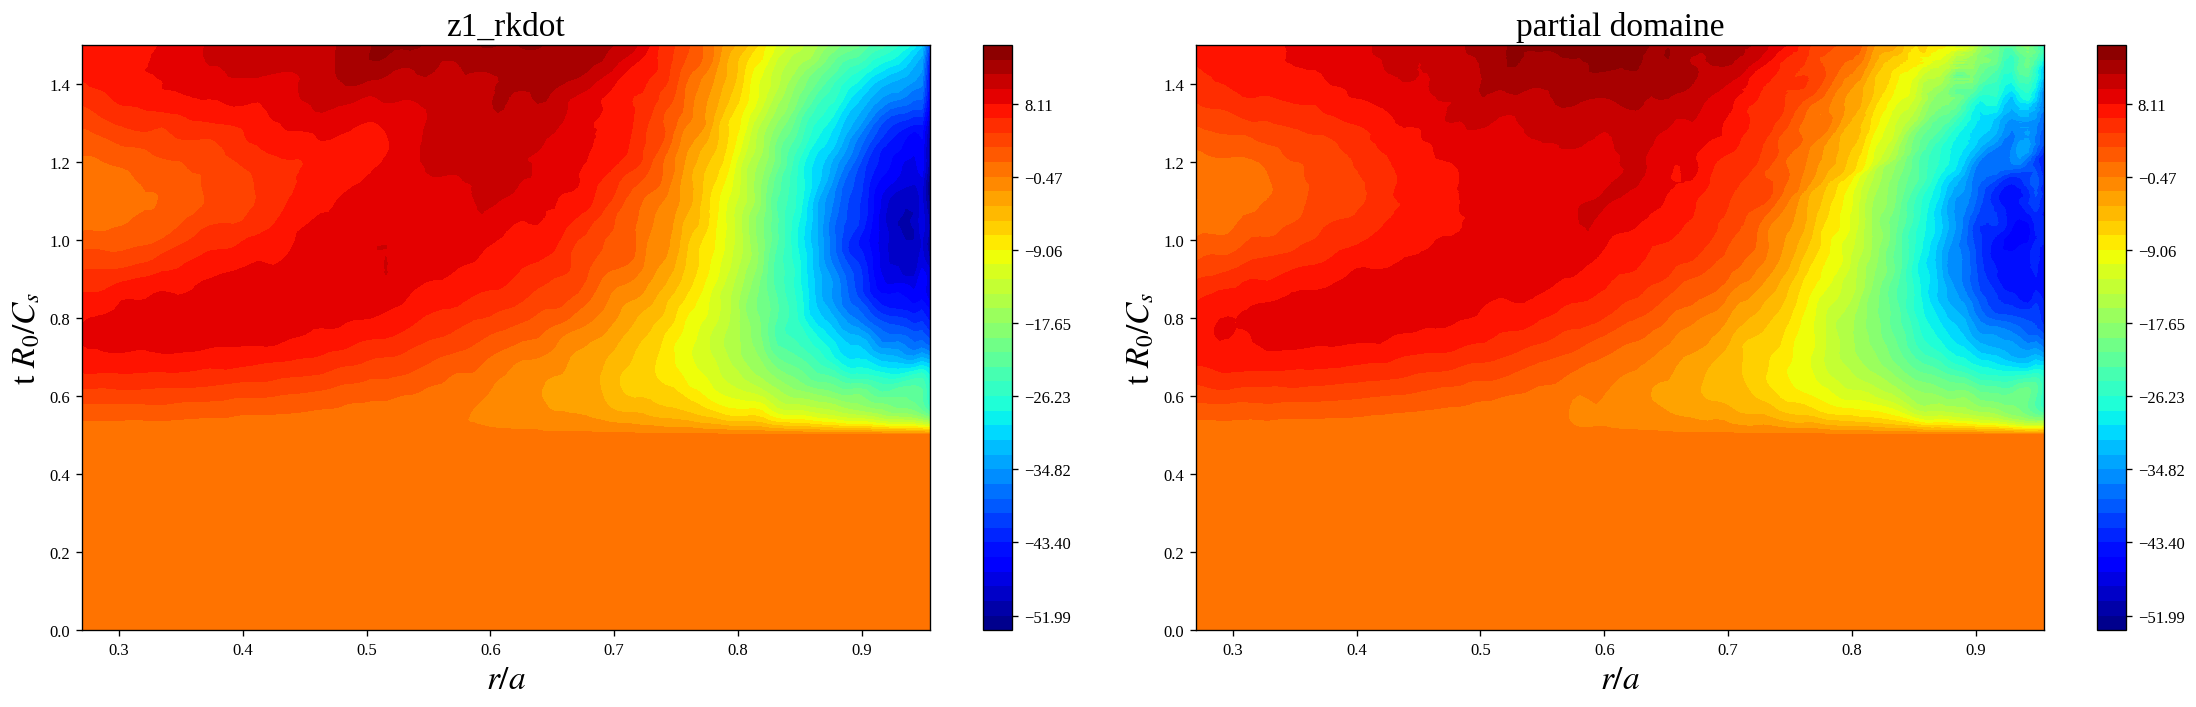

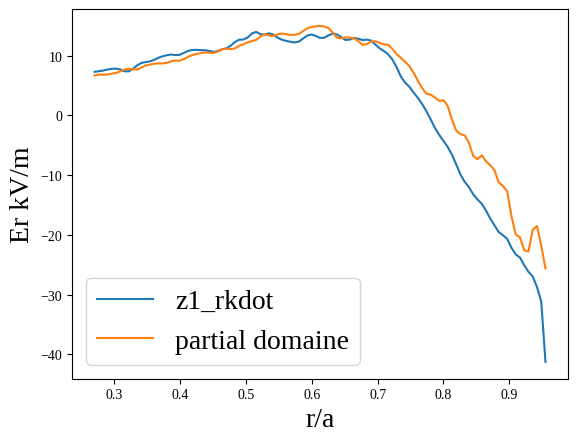

(<Figure size 2280x720 with 4 Axes>,
 <module 'matplotlib.pyplot' from '/ccs/home/emgreen/venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>)

In [20]:
data1d.compare_profile_vs_time(
    case_paths=[
                "/lustre/orion/scratch/emgreen/fus145/stellarator/self_consistent_Er/183281/z1_rkdot",
                "/lustre/orion/scratch/emgreen/fus145/stellarator/self_consistent_Er/183281/z1",
                #"/lustre/orion/scratch/emgreen/fus145/stellarator/self_consistent_Er/183281/partial_dom_0edge",
                #"/lustre/orion/scratch/emgreen/fus145/stellarator/self_consistent_Er/2024_experiment/192111/45",
                ],
    title=['z1_rkdot','partial domaine','192111t45'],
    ndstep=6000,
    ndstart=0,
    tstep=0.00025,
    psi_trim_low=20,
    psi_trim_high=2,
    particletype=4,
    kind=0
)

{'nue_eff': 0.02365342709027406, 'nui_eff': 0.004570417722860703, 'tstep': 2.9761156680076755, 'rg0': 0.0, 'rg1': 1.0, 'psi0': 0.0, 'spdpsi': 0.0001250020024946303, '4th': 0.0, '5th': 1.0, 'a_minor': 0.17849083566565593}


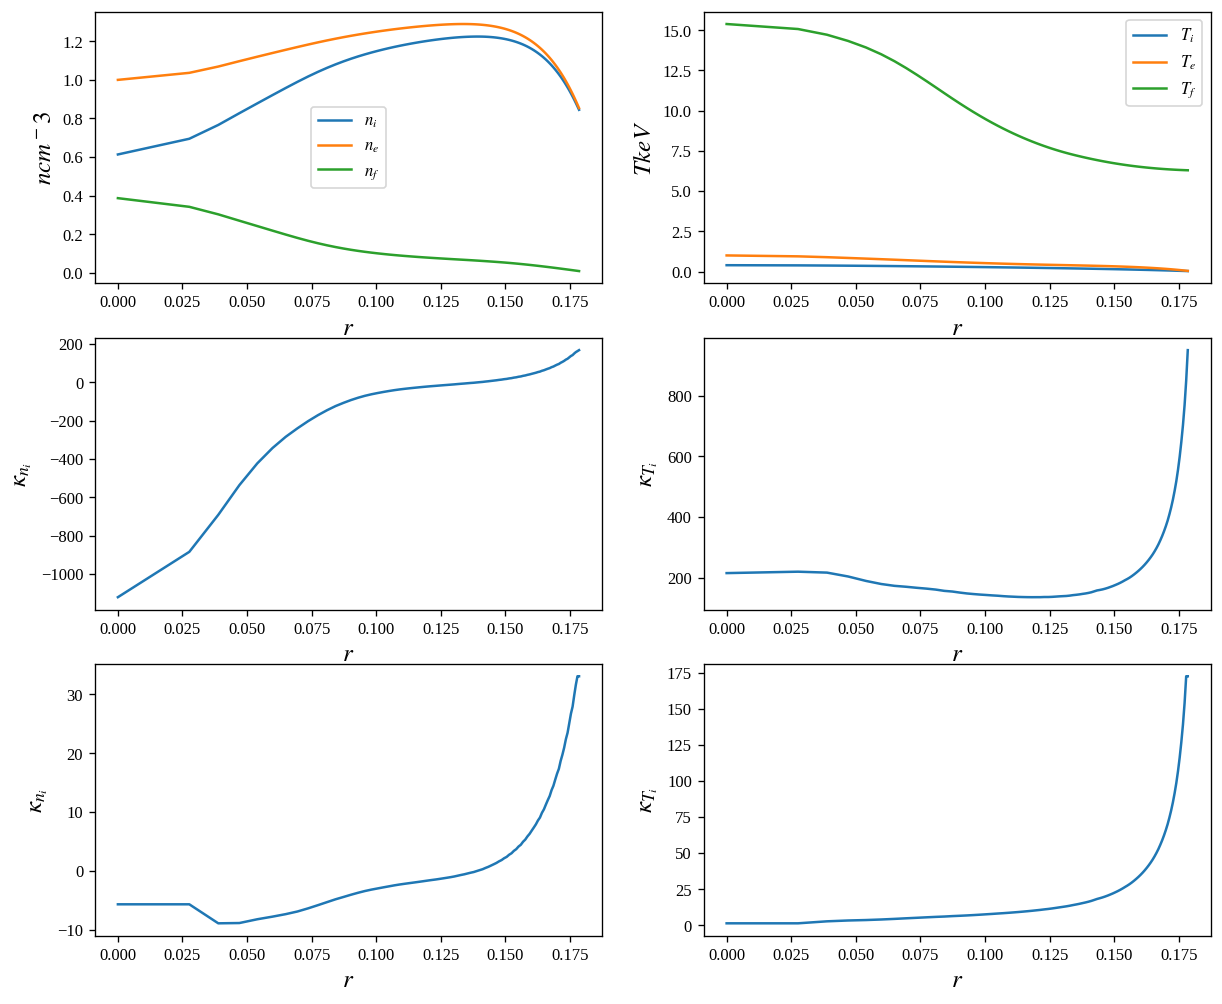

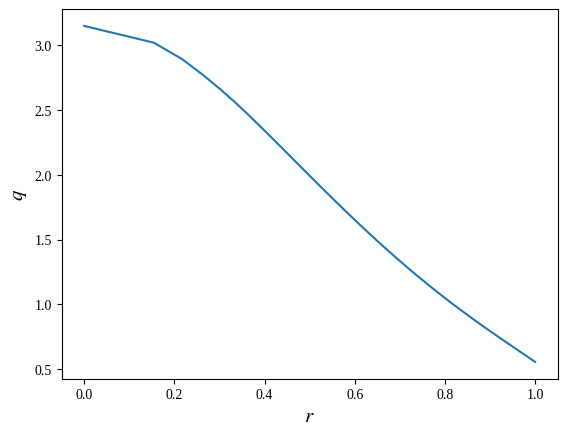

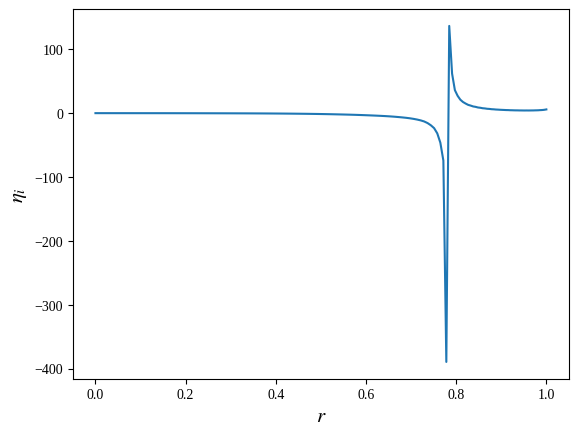

In [4]:
case_path="/lustre/orion/scratch/emgreen/fus145/stellarator/self_consistent_Er/2024_experiment/192111/45_ii0_delf"
plot_profiles(case_path,fast = True, vs_r = True)